# PHYS 142/242 — Assignment 1: Harmonic Oscillator Path Integral

Units: $m=\omega=\hbar=1$, so the classical period is $T_0=2\pi$.
Grid: $x_0=-4,\dots,x_{N_D}=+4$ with $N_D=600$; time step $\epsilon=T_0/128$.

**How to run:** *Kernel → Restart & Run All*. It takes about a minute. Requires `numpy` and `matplotlib` (Pillow, which matplotlib already depends on, writes the `.gif`).
The only thing to edit is `TSN` in the next cell.

Outputs written next to this notebook:

| file | problem |
|---|---|
| `results.json` | autograded results (A–D) |
| `figs/K8eps.txt` | A: truncated print of $K_{8\epsilon}$ |
| `figs/mean_x.pdf` | B: $\langle x\rangle$ vs $t$ |
| `figs/energy.pdf` | C: $\langle E\rangle,\langle K\rangle,\langle V\rangle$ vs $t$ |
| `figs/snapshots.pdf`, `figs/amplitudes.pdf` | D: $P_t(x)$ (with $V(x)$) and $\Psi_t(x)$ at $t=mT_0/16$ |
| `animation.gif`, `figs/anim_frames.pdf` | E: animation (129 frames) and stills |
| `figs/norm.pdf`, `figs/norm_scan.pdf` | F (bonus): norm without renormalization |
| `figs/numbers.txt`, `figs/numbers.tex` | numbers quoted in the report |

In [1]:
# Student-specific parameter: Triton Student Number (TSN)
TSN = "212345678"  # <-- replace with your own 9-digit TSN

In [2]:
import os

# Cap the BLAS thread count *before* importing numpy. On many-core machines the default
# (one thread per core) makes the 601x601 matrix-vector products ~100x slower.
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(var, "4")

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

HERE = os.getcwd()                    # outputs go next to the notebook
FIGS = os.path.join(HERE, "figs")
os.makedirs(FIGS, exist_ok=True)

notes = []                            # numbers quoted in the report, saved at the end
def note(s):
    notes.append(s)
    print(s)

T_TICKS = (np.arange(5) * 2 * np.pi / 4,
           ["0", r"$T_0/4$", r"$T_0/2$", r"$3T_0/4$", r"$T_0$"])

## Setup

$x_{\rm start}$ comes from the TSN, Eq. (3): $x_{\rm start}=(-1)^s\,(0.5+d/200)$. Here $d$ is the last two digits and $s$ is the third-to-last digit.

In [3]:
def x_start_from_tsn(tsn):
    # Eq. (3): d = last two digits, s = third-to-last digit; sign + if s even, - if s odd
    d = int(tsn[-2:])
    s = int(tsn[-3])
    return (-1) ** s * (0.5 + d / 200)

assert x_start_from_tsn("212345678") == 0.89     # examples given in the assignment
assert x_start_from_tsn("212345123") == -0.615

T0 = 2 * np.pi       # classical period
ALPHA = 2.0          # width parameter of the initial Gaussian, Eq. (2)
N_D = 600            # number of grid intervals (N_D + 1 grid points)
N_STEPS = 128        # time steps per period
eps = T0 / N_STEPS   # time step

x_start = x_start_from_tsn(TSN)
note(f"TSN = {TSN},  x_start = {x_start}")

TSN = 212345678,  x_start = 0.89


In [4]:
def make_grid(n_d):
    # x_0 = -4, ..., x_{n_d} = +4  (n_d + 1 points) and the spacing dx
    x = np.linspace(-4.0, 4.0, n_d + 1)
    return x, x[1] - x[0]


def initial_psi(x, x_start, alpha=ALPHA):
    # Eq. (2): normalized Gaussian centered at x_start, stored as a complex vector
    return ((alpha / np.pi) ** 0.25 * np.exp(-alpha / 2 * (x - x_start) ** 2)).astype(np.complex128)


def propagator_matrix(x, t):
    # Exact HO propagator K(x_b, t; x_a, 0), Eq. (4), with m = omega = hbar = 1.
    # Row index = final position x_b, column index = initial position x_a, so that
    #     psi(x_b, t) = sum_a K[b, a] psi(x_a, 0) dx   ->   psi_new = dx * K @ psi
    s, c = np.sin(t), np.cos(t)
    xb = x[:, None]                               # varies down the rows
    xa = x[None, :]                               # varies along the columns
    prefactor = np.sqrt(1.0 / (2j * np.pi * s))   # principal branch: e^{-i pi/4}/sqrt(2 pi sin t)
    return prefactor * np.exp(1j * ((xa**2 + xb**2) * c - 2 * xa * xb) / (2 * s))


def evolve(psi0, K_eps, dx, n_steps):
    # psi_{n+1} = dx * K_eps @ psi_n.  Returns psi at all n_steps + 1 times (rows).
    # The state is never renormalized.
    psi = np.empty((n_steps + 1, psi0.size), dtype=np.complex128)
    psi[0] = psi0
    A = dx * K_eps
    for n in range(n_steps):
        psi[n + 1] = A @ psi[n]
    return psi


x, dx = make_grid(N_D)
t = np.arange(N_STEPS + 1) * eps
print(f"dx = {dx:.6f}, eps = {eps:.6f}, grid points = {x.size}")

dx = 0.013333, eps = 0.049087, grid points = 601


## Problem A: $K_{8\epsilon}$

From Eq. (5), $K_{8\epsilon}=(\Delta x)^{7}K_\epsilon^{8}$: eight steps of the one-step matrix, with one factor of $\Delta x$ for each of the seven intermediate sums.
As a check, we apply it to $\psi_0$ and compare with Eq. (4) evaluated directly at $t=8\epsilon$.

In [5]:
K_eps = propagator_matrix(x, eps)
K_8eps = dx**7 * np.linalg.matrix_power(K_eps, 8)

print(K_8eps)                                   # default (truncated) NumPy output
with open(os.path.join(FIGS, "K8eps.txt"), "w") as f:
    f.write(str(K_8eps) + "\n")

# Check: acting on the initial state, K_8eps should reproduce the exact propagator Eq. (4) at
# t = 8 eps. (Comparing the matrices element by element is not meaningful: a point-source kernel
# spreads over all x and all momenta, so its entries depend on the box size and the grid cutoff.
# On a smooth, localized state like psi_0 those effects drop out.)
psi0 = initial_psi(x, x_start)
psi_8 = dx * K_8eps @ psi0
psi_8_exact = dx * propagator_matrix(x, 8 * eps) @ psi0
err_A = np.abs(psi_8 - psi_8_exact).max() / np.abs(psi_8_exact).max()
note(f"A: max|K_8eps psi0 - K(8eps) psi0| / max|K(8eps) psi0| = {err_A:.2e}")

[[-0.05955846+0.0178667j  -0.0757611 +0.0217024j  -0.07967385+0.05414053j
  ... -0.46505982-0.30932634j -0.35439299-0.42735575j
  -0.21687407-0.50917202j]
 [-0.0757611 +0.0217024j  -0.0896081 +0.03330227j -0.08308486+0.06724787j
  ... -0.53404108-0.16837676j -0.46141968-0.31131639j
  -0.35439299-0.42735575j]
 [-0.07967385+0.05414053j -0.08308486+0.06724787j -0.06226964+0.09303051j
  ... -0.56407376-0.01040964j -0.53404108-0.16837676j
  -0.46505982-0.30932634j]
 ...
 [-0.46505982-0.30932634j -0.53404108-0.16837676j -0.56407376-0.01040964j
  ... -0.06226964+0.09303051j -0.08308486+0.06724787j
  -0.07967385+0.05414053j]
 [-0.35439299-0.42735575j -0.46141968-0.31131639j -0.53404108-0.16837676j
  ... -0.08308486+0.06724787j -0.0896081 +0.03330227j
  -0.0757611 +0.0217024j ]
 [-0.21687407-0.50917202j -0.35439299-0.42735575j -0.46505982-0.30932634j
  ... -0.07967385+0.05414053j -0.0757611 +0.0217024j
  -0.05955846+0.0178667j ]]
A: max|K_8eps psi0 - K(8eps) psi0| / max|K(8eps) psi0| = 1.62e-04

## Problem B: $\langle x\rangle(t)$ over one period

We evolve 128 steps and compute $\langle x\rangle=\int x\,P_t(x)\,dx\approx\Delta x\sum_i x_i|\Psi_t(x_i)|^2$.
By Ehrenfest's theorem the result should follow the classical trajectory $x_{\rm start}\cos t$.

B: max|<x> - x_start cos t| = 1.04e-03
B: <x>(T0) = 0.889175
B: norm stays within [0.9994040409, 0.9999999998]


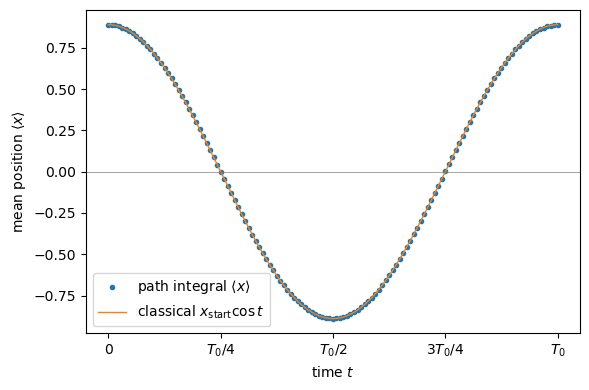

In [6]:
psi = evolve(initial_psi(x, x_start), K_eps, dx, N_STEPS)   # shape (129, 601)
P = np.abs(psi) ** 2                                       # P_t(x_i) at every step

norm = P.sum(axis=1) * dx                  # should stay 1 (no renormalization applied)
x_mean = (x * P).sum(axis=1) * dx          # Eq. (6)

note(f"B: max|<x> - x_start cos t| = {np.abs(x_mean - x_start * np.cos(t)).max():.2e}")
note(f"B: <x>(T0) = {x_mean[-1]:.6f}")
note(f"B: norm stays within [{norm.min():.10f}, {norm.max():.10f}]")
# The ~6e-4 norm loss is probability leaking past the box edges at x = +-4 (the state's tails
# reach there around t = T0/4, 3T0/4); with a box of +-6 at the same dx the loss drops to ~3e-8.

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, x_mean, "o", ms=3, label=r"path integral $\langle x\rangle$")
ax.plot(t, x_start * np.cos(t), "-", lw=1, label=r"classical $x_{\rm start}\cos t$")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xticks(*T_TICKS)
ax.set_xlabel(r"time $t$")
ax.set_ylabel(r"mean position $\langle x\rangle$")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "mean_x.pdf"))
plt.show()

## Problem C: $\langle E\rangle$, $\langle K\rangle$, $\langle V\rangle$

$\langle V\rangle=\Delta x\sum_i\tfrac12x_i^2P_t(x_i)$. $\langle K\rangle=\tfrac12\Delta x\sum_i|\partial_x\Psi_t(x_i)|^2$ (Eq. 8), with the derivative taken by second-order central differences (`np.gradient`).

Analytic check: for the initial Gaussian, $\langle V\rangle(0)=\tfrac12x_{\rm start}^2+\tfrac1{4\alpha}$ and $\langle K\rangle(0)=\tfrac{\alpha}{4}$. $\langle E\rangle$ is conserved.

C: <K>(0) = 0.499911 (exact 0.500000),  <V>(0) = 0.521050 (exact 0.521050)
C: <E> exact = 1.021050; numerical <E> in [1.017850, 1.021438]
C: <K> range [0.4956, 0.5238],  <V> range [0.4953, 0.5223]


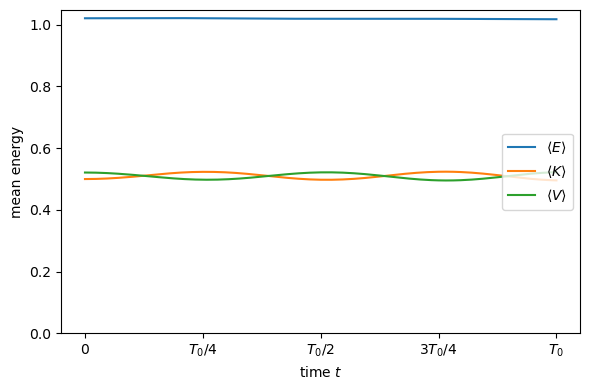

In [7]:
V = (0.5 * x**2 * P).sum(axis=1) * dx                       # Eq. (7)
dpsi_dx = np.gradient(psi, dx, axis=1)                      # central differences in x
K = (0.5 * np.abs(dpsi_dx) ** 2).sum(axis=1) * dx           # Eq. (8)
E = K + V

V0_exact = 0.5 * x_start**2 + 1 / (4 * ALPHA)
K0_exact = ALPHA / 4
note(f"C: <K>(0) = {K[0]:.6f} (exact {K0_exact:.6f}),  <V>(0) = {V[0]:.6f} (exact {V0_exact:.6f})")
note(f"C: <E> exact = {K0_exact + V0_exact:.6f}; numerical <E> in [{E.min():.6f}, {E.max():.6f}]")
note(f"C: <K> range [{K.min():.4f}, {K.max():.4f}],  <V> range [{V.min():.4f}, {V.max():.4f}]")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, E, label=r"$\langle E\rangle$")
ax.plot(t, K, label=r"$\langle K\rangle$")
ax.plot(t, V, label=r"$\langle V\rangle$")
ax.set_xticks(*T_TICKS)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"time $t$")
ax.set_ylabel("mean energy")
ax.legend(loc="center right")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "energy.pdf"))
plt.show()

## Problem D: amplitudes at $t=mT_0/16$, $m=0,\dots,8$

$T_0/16 = 8\epsilon$, so these are steps $0, 8, 16, \dots, 64$.
The first plot shows $P_t(x)=|\Psi_t(x)|^2$ with $V(x)$ superimposed (the optional part). The second shows $\mathrm{Re}\,\Psi_t$ and $\mathrm{Im}\,\Psi_t$.

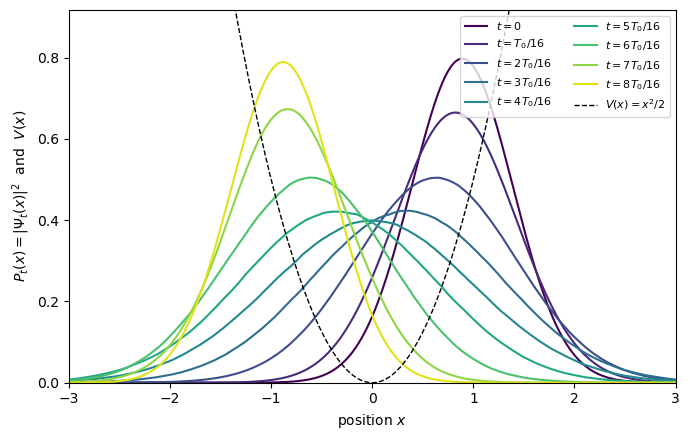

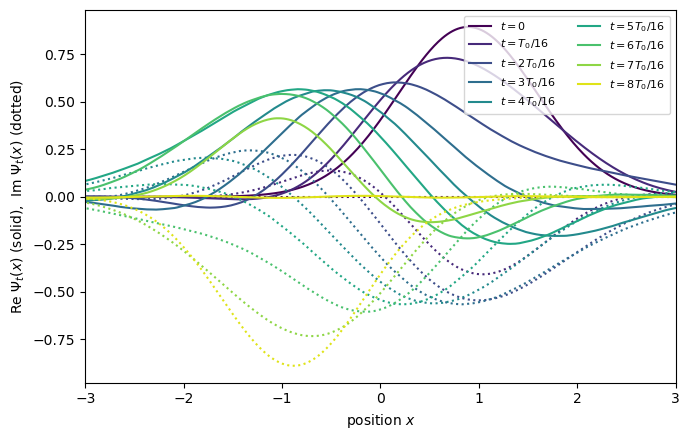

In [8]:
snap_idx = [8 * m for m in range(9)]
P_list = [P[n] for n in snap_idx]               # m = 0..8, used in results.json
colors = plt.cm.viridis(np.linspace(0, 0.95, 9))
labels = ["$t=0$", "$t=T_0/16$"] + [rf"$t={m}T_0/16$" for m in range(2, 9)]

# Probability densities + potential
fig, ax = plt.subplots(figsize=(7, 4.5))
for P_t, c, lab in zip(P_list, colors, labels):
    ax.plot(x, P_t, color=c, label=lab)
ax.plot(x, 0.5 * x**2, "k--", lw=1, label=r"$V(x)=x^2/2$")
ax.set_xlim(-3, 3)
ax.set_ylim(0, 1.15 * max(p.max() for p in P_list))
ax.set_xlabel(r"position $x$")
ax.set_ylabel(r"$P_t(x)=|\Psi_t(x)|^2$  and  $V(x)$")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "snapshots.pdf"))
plt.show()

# Complex amplitudes: Re (solid), Im (dotted)
fig, ax = plt.subplots(figsize=(7, 4.5))
for n, c, lab in zip(snap_idx, colors, labels):
    ax.plot(x, psi[n].real, color=c, label=lab)
    ax.plot(x, psi[n].imag, color=c, ls=":")
ax.set_xlim(-3, 3)
ax.set_xlabel(r"position $x$")
ax.set_ylabel(r"Re $\Psi_t(x)$ (solid),  Im $\Psi_t(x)$ (dotted)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "amplitudes.pdf"))
plt.show()

## Problem E: animation over one period

One frame per time step: 129 frames covering $t=0,\epsilon,\dots,128\epsilon=T_0$. Saved as `animation.gif`.

saved animation.gif with 129 frames


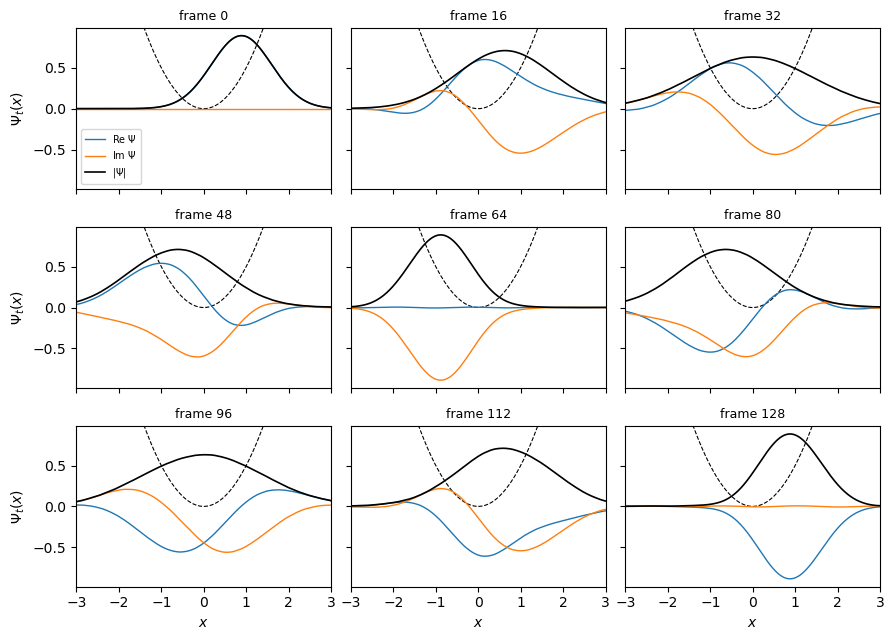

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
amp_max = np.abs(psi).max()
ax.plot(x, 0.5 * x**2, "k--", lw=1, label=r"$V(x)$")
line_re, = ax.plot([], [], lw=1, label=r"Re $\Psi$")
line_im, = ax.plot([], [], lw=1, label=r"Im $\Psi$")
line_abs, = ax.plot([], [], "k", lw=1.5, label=r"$|\Psi|$")
ax.set_xlim(-3, 3)
ax.set_ylim(-1.1 * amp_max, 1.1 * amp_max)
ax.set_xlabel(r"position $x$")
ax.set_ylabel(r"$\Psi_t(x)$")
ax.legend(loc="upper right", fontsize=8)
title = ax.set_title("")

def update(n):
    line_re.set_data(x, psi[n].real)
    line_im.set_data(x, psi[n].imag)
    line_abs.set_data(x, np.abs(psi[n]))
    title.set_text(rf"step {n}/128,  $t = {n}\,T_0/128$")
    return line_re, line_im, line_abs, title

anim = FuncAnimation(fig, update, frames=N_STEPS + 1)
anim.save(os.path.join(HERE, "animation.gif"), writer=PillowWriter(fps=20))
plt.close(fig)
print("saved animation.gif with", N_STEPS + 1, "frames")

# A few stills of the animation for the report (frames 0, 16, 32, ..., 128)
frames = range(0, N_STEPS + 1, 16)
fig, axes = plt.subplots(3, 3, figsize=(9, 6.5), sharex=True, sharey=True)
for ax_k, n in zip(axes.flat, frames):
    ax_k.plot(x, 0.5 * x**2, "k--", lw=0.8)
    ax_k.plot(x, psi[n].real, lw=1, label=r"Re $\Psi$")
    ax_k.plot(x, psi[n].imag, lw=1, label=r"Im $\Psi$")
    ax_k.plot(x, np.abs(psi[n]), "k", lw=1.2, label=r"$|\Psi|$")
    ax_k.set_title(f"frame {n}", fontsize=9)
    ax_k.set_xlim(-3, 3)
    ax_k.set_ylim(-1.1 * amp_max, 1.1 * amp_max)
axes[0, 0].legend(fontsize=7, loc="lower left")
for ax_k in axes[-1]:
    ax_k.set_xlabel(r"$x$")
for ax_k in axes[:, 0]:
    ax_k.set_ylabel(r"$\Psi_t(x)$")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "anim_frames.pdf"))
plt.show()

## Autograded output: `results.json`

In [10]:
results = {
    "tsn": TSN,
    "x_start": x_start,
    "K8eps_row": {"re": K_8eps[300].real.tolist(),      # row N_D/2 = 300 (x = 0)
                  "im": K_8eps[300].imag.tolist()},
    "x_mean": x_mean.tolist(),
    "V": V.tolist(), "K": K.tolist(), "E": E.tolist(),
    "P": [P_t.tolist() for P_t in P_list],
}
with open(os.path.join(HERE, "results.json"), "w") as f:
    json.dump(results, f)

# quick format check
assert len(results["K8eps_row"]["re"]) == 601 and len(results["x_mean"]) == 129
assert len(results["P"]) == 9 and all(len(p) == 601 for p in results["P"])
print("wrote results.json")

wrote results.json


## Problem F (bonus): norm without renormalization

$\mathcal N(t)=\Delta x\sum_i|\Psi_t(x_i)|^2$ for three cases:
(i) $\epsilon=T_0/16$, $N_D=600$; (ii) $\epsilon=T_0/512$, $N_D=600$; (iii) $\epsilon=T_0/128$, $N_D=150$.

**Prediction (before running):** The kernel phase is $\phi=[(x_a^2+x_b^2)\cos\epsilon-2x_ax_b]/(2\sin\epsilon)$. As a function of $x_a$ it oscillates with local wavenumber $|\partial\phi/\partial x_a|=|x_a\cos\epsilon-x_b|/\sin\epsilon$. This is up to $\approx 8/\sin\epsilon$ on our box, since $|x_a\cos\epsilon - x_b|\le 8$.
Small $\epsilon$ makes the kernel oscillate faster, so the grid eventually cannot resolve it.
Simple Nyquist estimate: the phase must advance by less than $\pi$ per grid spacing, i.e. $8\Delta x/\sin\epsilon<\pi$.
- (i) $\sin\epsilon=0.38$, $\Delta x=0.0133$: $8\Delta x/\sin\epsilon\approx0.28$. Should work.
- (ii) $\sin\epsilon=0.0123$: $\approx8.7$. **Should fail.**
- (iii) $\Delta x=0.0533$, $\sin\epsilon=0.049$: $\approx8.7$. **Should fail.**
- (main run) $\sin\epsilon=0.049$, $\Delta x=0.0133$: $\approx2.2$. Works.

F: eps=T0/16, N_D=600: N(T0) = 9.9946e-01, N after 1 step = 1.0000e+00, growth/step ~ 1.0000
F: eps=T0/512, N_D=600: N(T0) = 1.1479e+258, N after 1 step = 1.0382e+00, growth/step ~ 3.1917
F: eps=T0/128, N_D=150: N(T0) = 4.0953e+51, N after 1 step = 1.0423e+00, growth/step ~ 2.5306


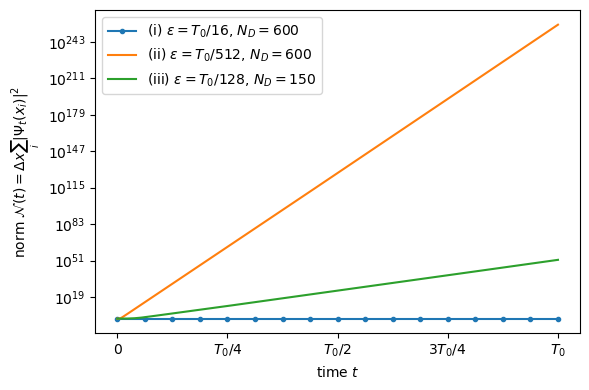

In [11]:
def run_norm(eps_c, n_d, t_final=T0):
    # Norm N(t) on [0, t_final] for time step eps_c and grid size n_d (no renormalization)
    xc, dxc = make_grid(n_d)
    n_steps = int(round(t_final / eps_c))
    psi_c = evolve(initial_psi(xc, x_start), propagator_matrix(xc, eps_c), dxc, n_steps)
    return np.arange(n_steps + 1) * eps_c, (np.abs(psi_c) ** 2).sum(axis=1) * dxc


norm_end = {}   # N(T0) for each case, used in the report
cases = [(T0 / 16, 600, r"(i) $\epsilon=T_0/16$, $N_D=600$"),
         (T0 / 512, 600, r"(ii) $\epsilon=T_0/512$, $N_D=600$"),
         (T0 / 128, 150, r"(iii) $\epsilon=T_0/128$, $N_D=150$")]

fig, ax = plt.subplots(figsize=(6, 4))
for eps_c, nd_c, lab in cases:
    t_c, N_c = run_norm(eps_c, nd_c)
    norm_end[(round(T0 / eps_c), nd_c)] = N_c[-1]
    ax.semilogy(t_c, N_c, "o-" if nd_c == 600 and eps_c > T0 / 64 else "-", ms=3, label=lab)
    note(f"F: eps=T0/{T0/eps_c:.0f}, N_D={nd_c}: N(T0) = {N_c[-1]:.4e}, "
         f"N after 1 step = {N_c[1]:.4e}, growth/step ~ {(N_c[-1]/N_c[0])**(1/(len(N_c)-1)):.4f}")
ax.set_xticks(*T_TICKS)
ax.set_xlabel(r"time $t$")
ax.set_ylabel(r"norm $\mathcal{N}(t)=\Delta x\sum_i|\Psi_t(x_i)|^2$")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "norm.pdf"))
plt.show()

### Smallest workable time step

We scan $\epsilon=T_0/n$ and record the deviation $|\mathcal N(T_0)-1|$ after one period, for $N_D=600$ and $N_D=1200$.

Two estimates are drawn on the plot:
- dotted: the simple Nyquist bound $\sin\epsilon_{\min}=8\Delta x/\pi$.
- dashed: the aliasing bound $\sin\epsilon_{\min}=8\Delta x/(2\pi)$.

Where the second bound comes from: by Poisson summation, $\Delta x\sum_j f(x_j)=\sum_m\int f(x)\,e^{2\pi i m x/\Delta x}dx$.
For $f=K_\epsilon\Psi$, the $m\neq0$ terms are normally negligible because they oscillate rapidly and cancel.
They only contribute when they have a stationary point, i.e. when $|\partial\phi/\partial x_a|$ reaches $2\pi/\Delta x$ somewhere on the grid.

F scan N_D=600: first n with |N(T0)-1| > 1e-3: n = 372 (eps = 0.0169);  pi estimate eps_min = 0.0340 = T0/185;  2pi estimate eps_min = 0.0170 = T0/370


/tmp/ipykernel_1066456/3298264480.py:6: RuntimeWarning: overflow encountered in square
  return np.arange(n_steps + 1) * eps_c, (np.abs(psi_c) ** 2).sum(axis=1) * dxc
/home/wenyu/others/PHYS142/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


F scan N_D=1200: first n with |N(T0)-1| > 1e-3: n = 744 (eps = 0.0084);  pi estimate eps_min = 0.0170 = T0/370;  2pi estimate eps_min = 0.0085 = T0/740


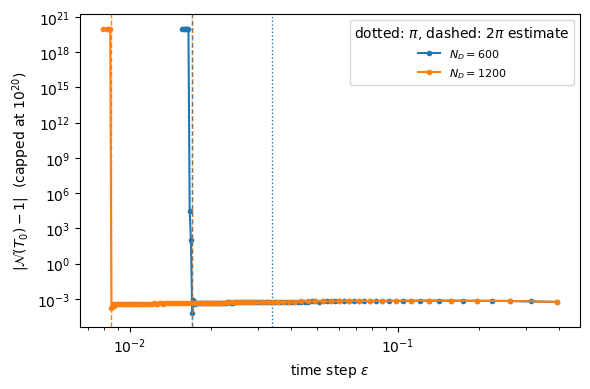

In [12]:
n_fail_by_nd = {}
fig, ax = plt.subplots(figsize=(6, 4))
for nd_c, n_list in ((600, np.arange(16, 401, 4)), (1200, np.arange(16, 801, 8))):
    N_end = np.array([run_norm(T0 / n, nd_c)[1][-1] for n in n_list])
    fails = n_list[np.abs(N_end - 1) > 1e-3]
    _, dx_c = make_grid(nd_c)
    eps_nyq = np.arcsin(8 * dx_c / np.pi)          # phase step pi per dx
    eps_alias = np.arcsin(8 * dx_c / (2 * np.pi))  # phase step 2 pi per dx
    n_fail = fails.min() if fails.size else None
    n_fail_by_nd[nd_c] = n_fail
    note(f"F scan N_D={nd_c}: first n with |N(T0)-1| > 1e-3: n = {n_fail} "
         f"(eps = {T0/n_fail if n_fail else float('nan'):.4f});  "
         f"pi estimate eps_min = {eps_nyq:.4f} = T0/{T0/eps_nyq:.0f};  "
         f"2pi estimate eps_min = {eps_alias:.4f} = T0/{T0/eps_alias:.0f}")
    dev = np.abs(N_end - 1)
    ok = np.isfinite(dev)                          # the worst cases overflow to inf
    # cap at 1e20 for plotting (larger values break the log-axis tick labels)
    (ln,) = ax.loglog(T0 / n_list[ok], np.clip(dev[ok], 1e-16, 1e20), "o-", ms=3,
                      label=rf"$N_D={nd_c}$")
    ax.axvline(eps_nyq, ls=":", color=ln.get_color(), lw=1)
    ax.axvline(eps_alias, ls="--", color=ln.get_color(), lw=1)
ax.set_xlabel(r"time step $\epsilon$")
ax.set_ylabel(r"$|\mathcal{N}(T_0)-1|$  (capped at $10^{20}$)")
ax.legend(title=r"dotted: $\pi$, dashed: $2\pi$ estimate", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "norm_scan.pdf"))
plt.show()

with open(os.path.join(FIGS, "numbers.txt"), "w") as f:
    f.write("\n".join(notes) + "\n")

## Numbers for the report

Writes `figs/numbers.tex`: LaTeX macros the report reads, so it updates automatically after a re-run.

In [13]:
def sci(v, digits=2):
    # format v as LaTeX scientific notation, e.g. 1.2\times10^{-3}
    m, e = f"{v:.{digits}e}".split("e")
    return rf"{m}\times10^{{{int(e)}}}"

macros = {
    "TSN": TSN,
    "xstart": f"{x_start:g}",
    "errA": sci(err_A),
    "devX": sci(np.abs(x_mean - x_start * np.cos(t)).max()),
    "xmeanEnd": f"{x_mean[-1]:.4f}",
    "normMin": f"{norm.min():.5f}",
    "Kzero": f"{K[0]:.5f}", "Vzero": f"{V[0]:.5f}",
    "Kexact": f"{K0_exact:.5f}", "Vexact": f"{V0_exact:.5f}",
    "Eexact": f"{K0_exact + V0_exact:.5f}",
    "Emin": f"{E.min():.5f}", "Emax": f"{E.max():.5f}",
    "Edev": f"{100 * np.abs(E - (K0_exact + V0_exact)).max() / (K0_exact + V0_exact):.2f}",
    "normI": f"{norm_end[(16, 600)]:.5f}",
    "normII": sci(norm_end[(512, 600)], 1),
    "normIII": sci(norm_end[(128, 150)], 1),
    "nFailSix": str(n_fail_by_nd[600]),
    "nFailTwelve": str(n_fail_by_nd[1200]),
}
with open(os.path.join(FIGS, "numbers.tex"), "w") as f:
    for k, v in macros.items():
        f.write(rf"\newcommand{{\{k}}}{{{v}}}" + "\n")
print(open(os.path.join(FIGS, "numbers.tex")).read())

\newcommand{\TSN}{212345678}
\newcommand{\xstart}{0.89}
\newcommand{\errA}{1.62\times10^{-4}}
\newcommand{\devX}{1.04\times10^{-3}}
\newcommand{\xmeanEnd}{0.8892}
\newcommand{\normMin}{0.99940}
\newcommand{\Kzero}{0.49991}
\newcommand{\Vzero}{0.52105}
\newcommand{\Kexact}{0.50000}
\newcommand{\Vexact}{0.52105}
\newcommand{\Eexact}{1.02105}
\newcommand{\Emin}{1.01785}
\newcommand{\Emax}{1.02144}
\newcommand{\Edev}{0.31}
\newcommand{\normI}{0.99946}
\newcommand{\normII}{1.1\times10^{258}}
\newcommand{\normIII}{4.1\times10^{51}}
\newcommand{\nFailSix}{372}
\newcommand{\nFailTwelve}{744}

